# Loss Functions — Illustrated

The choice of loss encodes **what kinds of mistakes you can tolerate**.

For regression we look at the residual $r = y - \hat y$.
For classification we look at the margin $m = y\,\hat f(x)$ where $y \in \{-1, +1\}$.


## The picture — the loss shape controls how each residual contributes

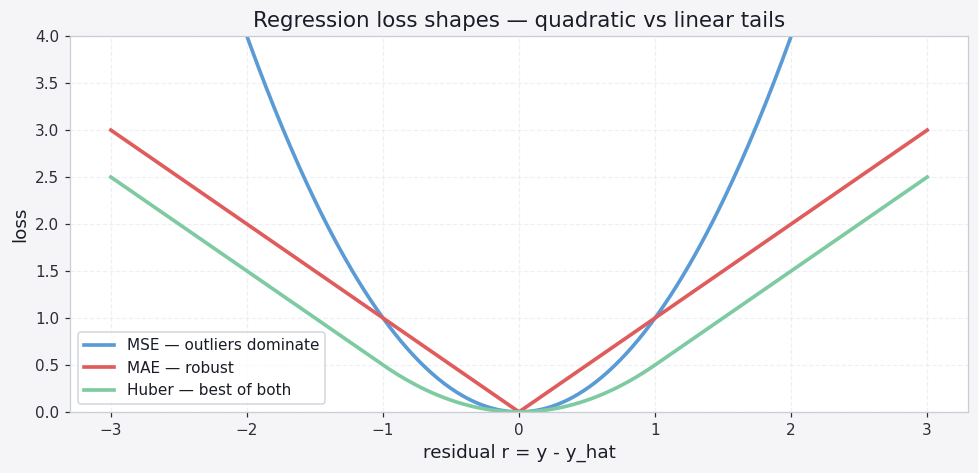

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
r = np.linspace(-3, 3, 400)
def huber(r, d=1.0):
    a = np.abs(r); return np.where(a<=d, 0.5*r*r, d*(a-0.5*d))
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(r, r**2, color=P[0], lw=2.4, label='MSE — outliers dominate')
ax.plot(r, np.abs(r), color=P[1], lw=2.4, label='MAE — robust')
ax.plot(r, huber(r), color=P[3], lw=2.4, label='Huber — best of both')
ax.set_xlabel('residual r = y - y_hat'); ax.set_ylabel('loss')
ax.set_title('Regression loss shapes — quadratic vs linear tails')
ax.legend(); ax.grid(True); ax.set_ylim(0, 4)
plt.tight_layout(); plt.show()


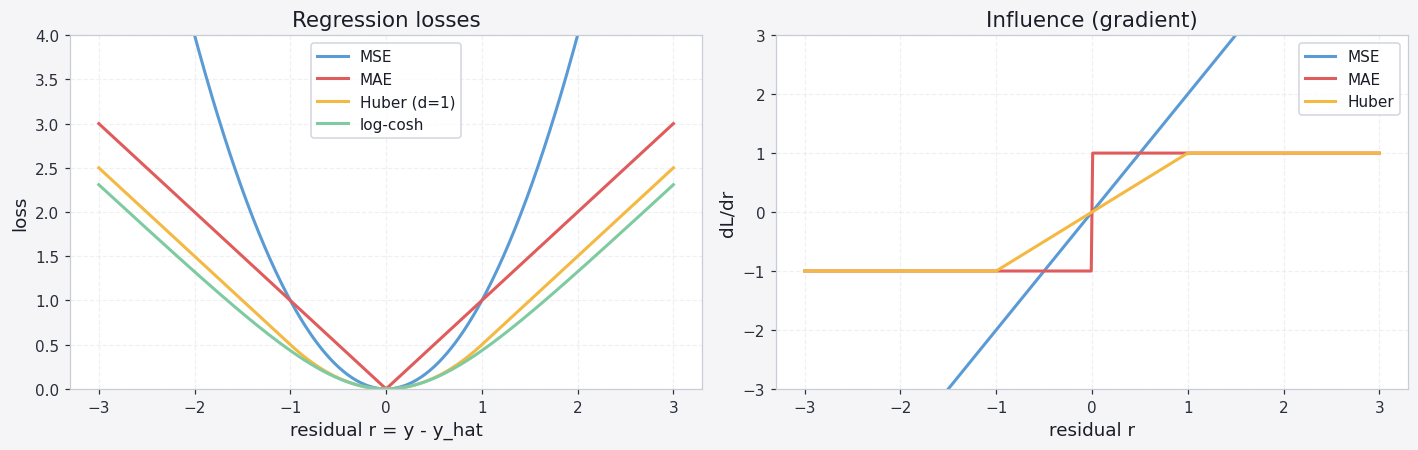

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

r = np.linspace(-3, 3, 400)
def mse(r):   return r**2
def mae(r):   return np.abs(r)
def huber(r, d=1.0):
    a = np.abs(r); return np.where(a<=d, 0.5*r*r, d*(a-0.5*d))
def logcosh(r): return np.log(np.cosh(r))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.plot(r, mse(r),   color=PALETTE[0], lw=2, label='MSE')
ax.plot(r, mae(r),   color=PALETTE[1], lw=2, label='MAE')
ax.plot(r, huber(r), color=PALETTE[2], lw=2, label='Huber (d=1)')
ax.plot(r, logcosh(r), color=PALETTE[3], lw=2, label='log-cosh')
ax.set_xlabel('residual r = y - y_hat'); ax.set_ylabel('loss')
ax.set_title('Regression losses'); ax.legend(); ax.grid(True)
ax.set_ylim(0, 4)

# Gradients (the influence of an outlier on the fit)
def dmse(r): return 2*r
def dmae(r): return np.sign(r)
def dhuber(r, d=1.0):
    return np.where(np.abs(r)<=d, r, d*np.sign(r))
ax = axes[1]
ax.plot(r, dmse(r),   color=PALETTE[0], lw=2, label='MSE')
ax.plot(r, dmae(r),   color=PALETTE[1], lw=2, label='MAE')
ax.plot(r, dhuber(r), color=PALETTE[2], lw=2, label='Huber')
ax.set_xlabel('residual r'); ax.set_ylabel('dL/dr')
ax.set_title('Influence (gradient)'); ax.legend(); ax.grid(True)
ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()


---
## Robustness in action

Fit each loss to a clean dataset and a copy with 5 outliers.


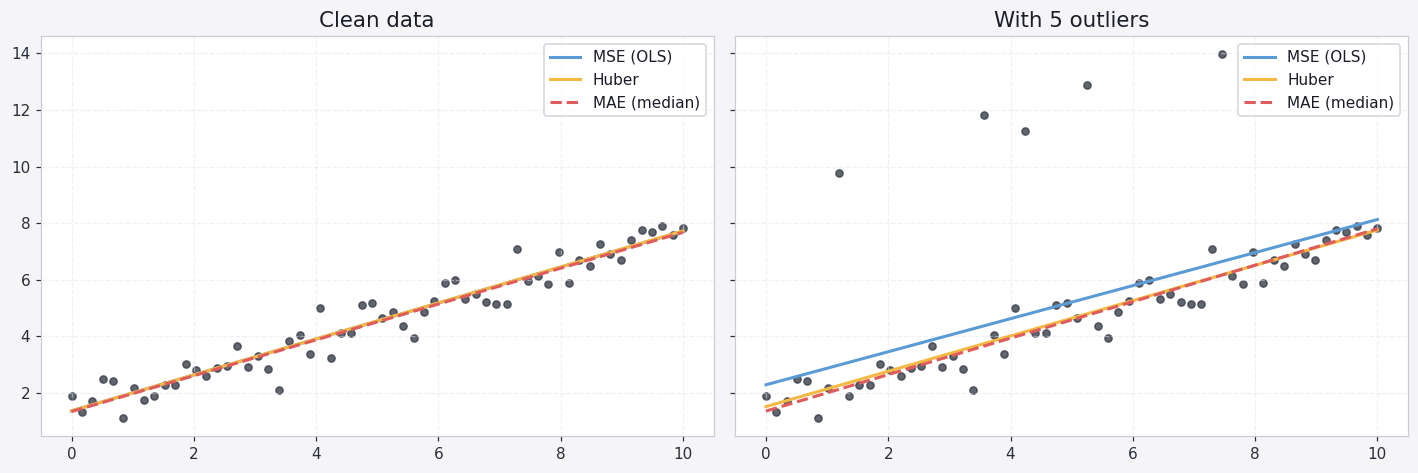

In [3]:
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.linear_model import QuantileRegressor

rng = np.random.RandomState(0)
n = 60
x = np.linspace(0, 10, n)
y = 0.7*x + 1 + 0.5*rng.randn(n)
y_out = y.copy(); idx = rng.choice(n, 5, replace=False); y_out[idx] += 8

def fit(model, x, y):
    return model.fit(x[:, None], y).predict(x[:, None])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, ydata, title in zip(axes, [y, y_out], ['Clean data', 'With 5 outliers']):
    ax.scatter(x, ydata, s=22, color='#3a3e4a', alpha=0.8)
    ax.plot(x, fit(LinearRegression(), x, ydata), color=PALETTE[0], lw=2, label='MSE (OLS)')
    ax.plot(x, fit(HuberRegressor(), x, ydata),  color=PALETTE[2], lw=2, label='Huber')
    ax.plot(x, fit(QuantileRegressor(quantile=0.5, alpha=0), x, ydata),
            color=PALETTE[1], lw=2, ls='--', label='MAE (median)')
    ax.set_title(title); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()


---
## Classification losses on the margin

For $y \in \{-1, +1\}$ and prediction $\hat f$, the *margin* $m = y\hat f$ is positive when correct.


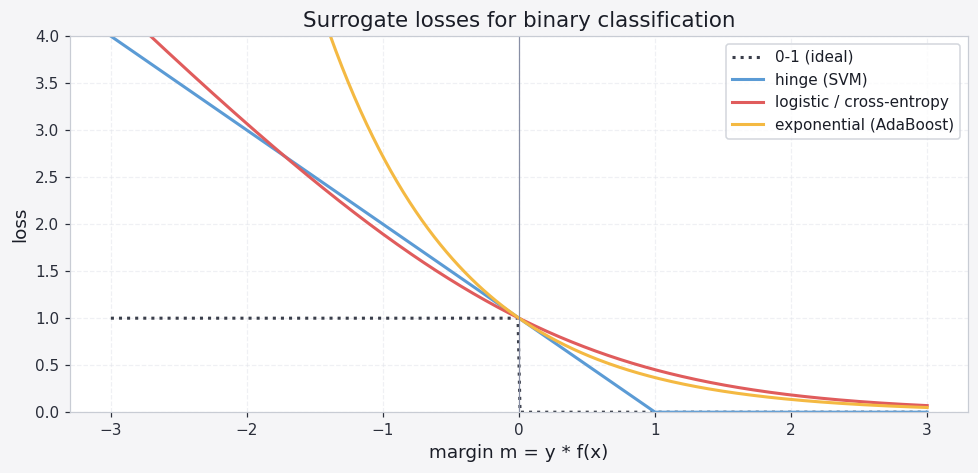

In [4]:
m = np.linspace(-3, 3, 400)
zero_one = (m < 0).astype(float)
hinge    = np.maximum(0, 1 - m)
logistic = np.log1p(np.exp(-m)) / np.log(2)   # base-2 so it crosses 1 at m=0
exp_loss = np.exp(-m)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(m, zero_one, color='#3a3e4a', lw=2, ls=':', label='0-1 (ideal)')
ax.plot(m, hinge,    color=PALETTE[0], lw=2, label='hinge (SVM)')
ax.plot(m, logistic, color=PALETTE[1], lw=2, label='logistic / cross-entropy')
ax.plot(m, exp_loss, color=PALETTE[2], lw=2, label='exponential (AdaBoost)')
ax.axvline(0, color='#888fa5', lw=0.8); ax.set_xlabel('margin m = y * f(x)')
ax.set_ylabel('loss'); ax.set_ylim(0, 4)
ax.set_title('Surrogate losses for binary classification')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


---
## When to use what

- **MSE** — fast, smooth gradients, but a single outlier can dominate the fit.
- **MAE / quantile** — robust to outliers; non-smooth gradient (sub-gradient) at zero.
- **Huber / log-cosh** — quadratic near zero, linear in the tails. The pragmatic default.
- **Hinge** — only mistakes contribute; gives sparse SVM solutions.
- **Cross-entropy** — calibrated probabilities (default for classification).
- **Exponential** — heavily up-weights mistakes; behind AdaBoost; sensitive to mislabels.

> **Try this**: in cell 3 add `from sklearn.linear_model import RANSACRegressor` and compare. RANSAC is even more robust because it discards outliers entirely.
